# Task
Perform a comprehensive Exploratory Data Analysis (EDA) on the Iris dataset.

## Initialize Notebook and Load Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure inline plotting and aesthetic theme
%matplotlib inline
sns.set_theme(style='whitegrid')
print('Libraries imported and visualization theme set.')

Libraries imported and visualization theme set.


# Iris Dataset Exploratory Data Analysis (EDA)

### Introduction
The Iris dataset is a classic dataset in machine learning and statistics, containing 150 samples from three species of Iris flowers: *Iris setosa*, *Iris virginica*, and *Iris versicolor*. Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

### Objectives
The primary goals of this EDA are:
1. **Data Inspection**: Load the data and understand its structure and statistical properties.
2. **Data Cleaning**: Identify and handle any missing or duplicated values.
3. **Feature Characterization**: Explore the distribution of individual features.
4. **Relationship Analysis**: Visualize correlations and interactions between features to identify patterns that distinguish the species.
5. **Insights**: Summarize key findings regarding the separability of the Iris species.

## Load and Inspect Dataset


In [2]:
df = sns.load_dataset('iris')
print('Dataset shape:', df.shape)
print('\n--- First 5 rows ---')
display(df.head())
print('\n--- Dataset Info ---')
df.info()
print('\n--- Summary Statistics ---')
display(df.describe())

Dataset shape: (150, 5)

--- First 5 rows ---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- Summary Statistics ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Data Cleaning and Feature Analysis

### Subtask:
Verify data integrity and characterize the features present in the Iris dataset.


**Reasoning**:
I will check for missing values, identify duplicates, and analyze the distribution of the 'species' column to ensure data integrity and characterize the features.



In [3]:
print('--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Duplicate Rows ---')
print(f'Number of duplicate rows: {df.duplicated().sum()}')

print('\n--- Species Distribution ---')
print(df['species'].value_counts())


--- Missing Values ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

--- Duplicate Rows ---
Number of duplicate rows: 1

--- Species Distribution ---
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### Feature Categorization

Based on the initial inspection, the features in the Iris dataset can be categorized as follows:

*   **Numerical Features**: These are continuous measurements (in cm).
    *   `sepal_length`
    *   `sepal_width`
    *   `petal_length`
    *   `petal_width`

*   **Categorical Feature**: This is the target variable representing the class of the flower.
    *   `species` (Setosa, Versicolor, Virginica)

### Data Integrity Observations
*   **Missing Values**: There are no missing values in the dataset.
*   **Duplicates**: There is 1 duplicate row present in the data.
*   **Class Balance**: The dataset is perfectly balanced with 50 samples for each of the three species.

## Visual Exploratory Data Analysis



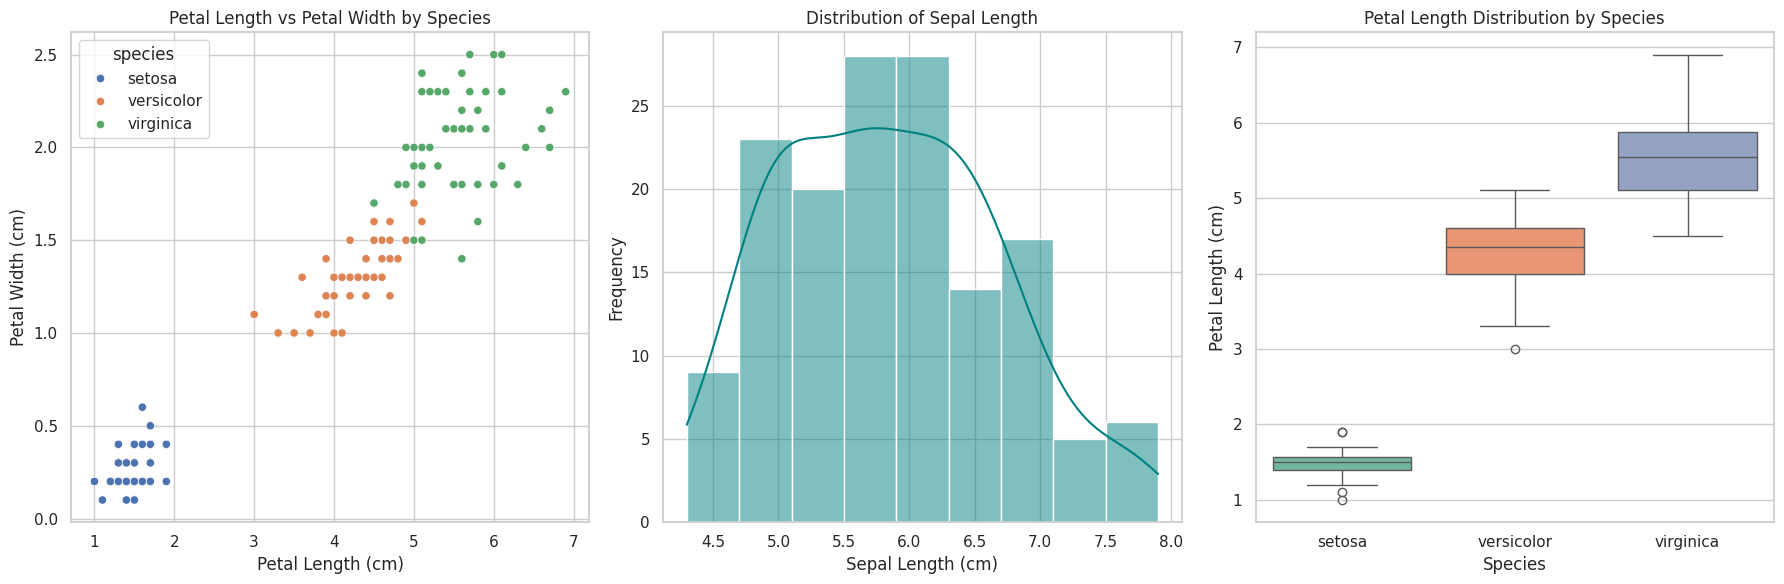

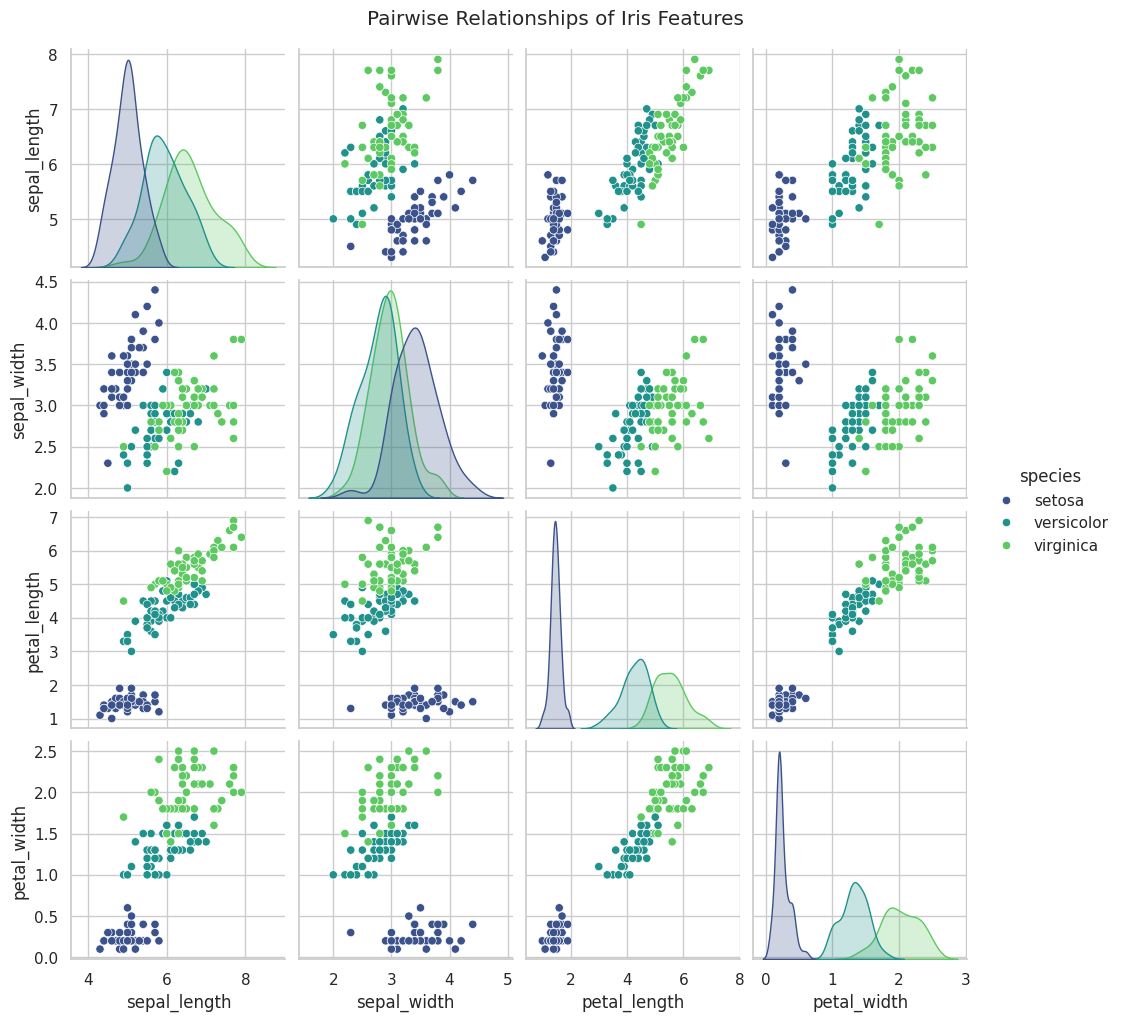

In [5]:
# Create a figure with subplots for the first three visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Scatter plot: Petal Length vs Petal Width
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', ax=axes[0])
axes[0].set_title('Petal Length vs Petal Width by Species')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# 2. Histogram: Sepal Length distribution
sns.histplot(data=df, x='sepal_length', kde=True, color='teal', ax=axes[1])
axes[1].set_title('Distribution of Sepal Length')
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Frequency')

# 3. Box plot: Petal Length across Species
sns.boxplot(data=df, x='species', y='petal_length', hue='species', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Petal Length Distribution by Species')
axes[2].set_xlabel('Species')
axes[2].set_ylabel('Petal Length (cm)')

plt.tight_layout()
plt.show()

# 4. Pairplot for all pairwise relationships
g = sns.pairplot(df, hue='species', palette='viridis', diag_kind='kde')
g.fig.suptitle('Pairwise Relationships of Iris Features', y=1.02)
plt.show()

## Feature Relationships and Insights




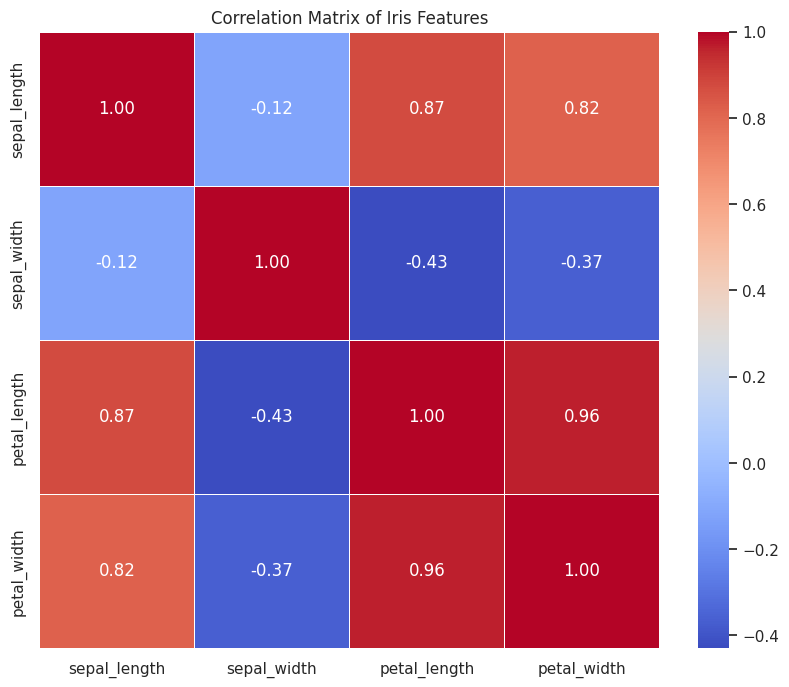

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


In [6]:
# Select only numerical columns for correlation calculation
numerical_df = df.drop(columns=['species'])
corr_matrix = numerical_df.corr()

# Create a heatmap to visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Iris Features')
plt.show()

print('Correlation Matrix:')
print(corr_matrix)

## Summary:

### Data Analysis Key Findings

*   **Dataset Integrity**: The dataset consists of 150 samples (50 for each of the three species) and is perfectly balanced. No missing values were found, though 1 duplicate row was identified.
*   **Petal vs. Sepal Variance**: The standard deviation for petal length (1.76) is significantly higher than for sepal width (0.43), indicating that petal dimensions vary much more across the species and serve as better discriminators.
*   **Setosa Uniqueness**: In the scatter plots and box plots, *Iris setosa* consistently registered much smaller petal values, making it the most easily identifiable species.
*   **Feature Redundancy**: The extremely high correlation (**0.96**) between `petal_length` and `petal_width` suggests that these two features provide redundant information, which could be relevant for feature selection in machine learning.
*   **Distribution Characteristics**: While `sepal_length` follows a relatively normal distribution across the entire dataset, the pairplot revealed that the distributions become multi-modal or distinct when broken down by species.

---

